In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")


Matplotlib is building the font cache; this may take a moment.


In [2]:
# Load dataset
df = pd.read_csv("Utility_consumption.csv")

# Display first rows
df.head()

,Datetime,Temperature,Humidity,WindSpeed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption
0,01-01-2017 00:00,6.559,73.8,0.083,34055.69620,16128.87538,20240.96386
1,01-01-2017 00:10,6.414,74.5,0.083,29814.68354,19375.07599,20131.08434
2,01-01-2017 00:20,6.313,74.5,0.080,29128.10127,19006.68693,19668.43373
3,01-01-2017 00:30,6.121,75.0,0.083,28228.86076,18361.09422,18899.27711
4,01-01-2017 00:40,5.921,75.7,0.081,27335.69620,17872.34043,18442.40964


In [3]:
# Dataset information
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Datetime                   52416 non-null  str    
 1   Temperature                52416 non-null  float64
 2   Humidity                   52416 non-null  float64
 3   WindSpeed                  52416 non-null  float64
 4   F1_132KV_PowerConsumption  52416 non-null  float64
 5   F2_132KV_PowerConsumption  52416 non-null  float64
 6   F3_132KV_PowerConsumption  52416 non-null  float64
dtypes: float64(6), str(1)
memory usage: 2.8 MB


In [4]:
# Statistical summary
df.describe()

,Temperature,Humidity,WindSpeed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,32344.970564,21042.509082,17835.406218
std,5.815476,15.551177,2.348862,7130.562564,5201.465892,6622.165099
min,3.247000,11.340000,0.050000,13895.696200,8560.081466,5935.174070
25%,14.410000,58.310000,0.078000,26310.668692,16980.766032,13129.326630
50%,18.780000,69.860000,0.086000,32265.920340,20823.168405,16415.117470
75%,22.890000,81.400000,4.915000,37309.018185,24713.717520,21624.100420
max,40.010000,94.800000,6.483000,52204.395120,37408.860760,47598.326360


In [5]:
# Check missing values
missing = df.isnull().sum()

print(missing)


Datetime                     0
Temperature                  0
Humidity                     0
WindSpeed                    0
F1_132KV_PowerConsumption    0
F2_132KV_PowerConsumption    0
F3_132KV_PowerConsumption    0
dtype: int64


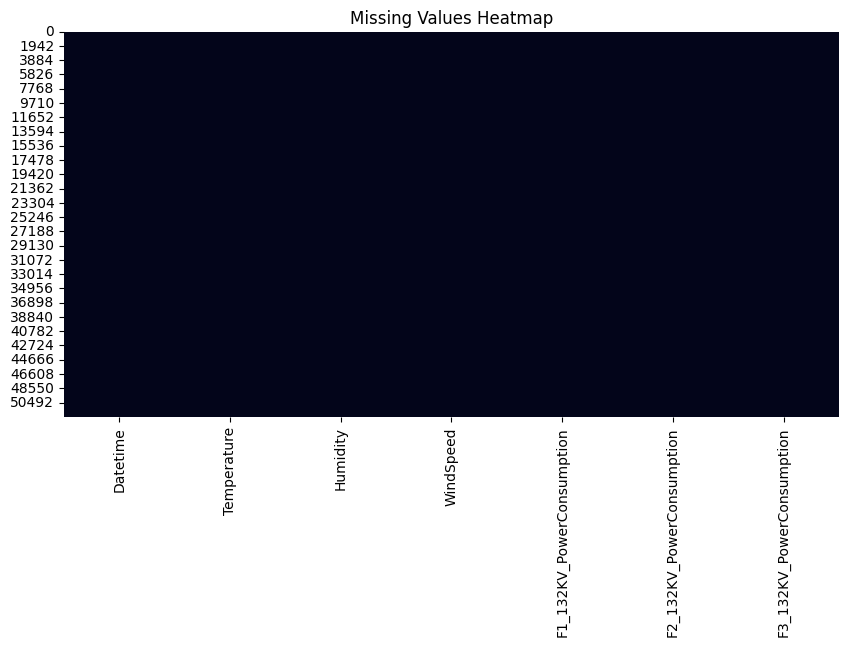

In [6]:
# Visualize missing values
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

In [7]:
# Forward fill missing values
df.ffill(inplace=True)

,Datetime,Temperature,Humidity,WindSpeed,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption
0,01-01-2017 00:00,6.559,73.8,0.083,34055.69620,16128.87538,20240.96386
1,01-01-2017 00:10,6.414,74.5,0.083,29814.68354,19375.07599,20131.08434
2,01-01-2017 00:20,6.313,74.5,0.080,29128.10127,19006.68693,19668.43373
3,01-01-2017 00:30,6.121,75.0,0.083,28228.86076,18361.09422,18899.27711
4,01-01-2017 00:40,5.921,75.7,0.081,27335.69620,17872.34043,18442.40964
...,...,...,...,...,...,...,...
52411,12/30/2017 23:10,7.010,72.4,0.080,31160.45627,26857.31820,14780.31212
52412,12/30/2017 23:20,6.947,72.6,0.082,30430.41825,26124.57809,14428.81152
52413,12/30/2017 23:30,6.900,72.8,0.086,29590.87452,25277.69254,13806.48259
52414,12/30/2017 23:40,6.758,73.0,0.080,28958.17490,24692.23688,13512.60504


In [8]:
power_cols = [
    "F1_132KV_PowerConsumption",
    "F2_132KV_PowerConsumption",
    "F3_132KV_PowerConsumption"
]

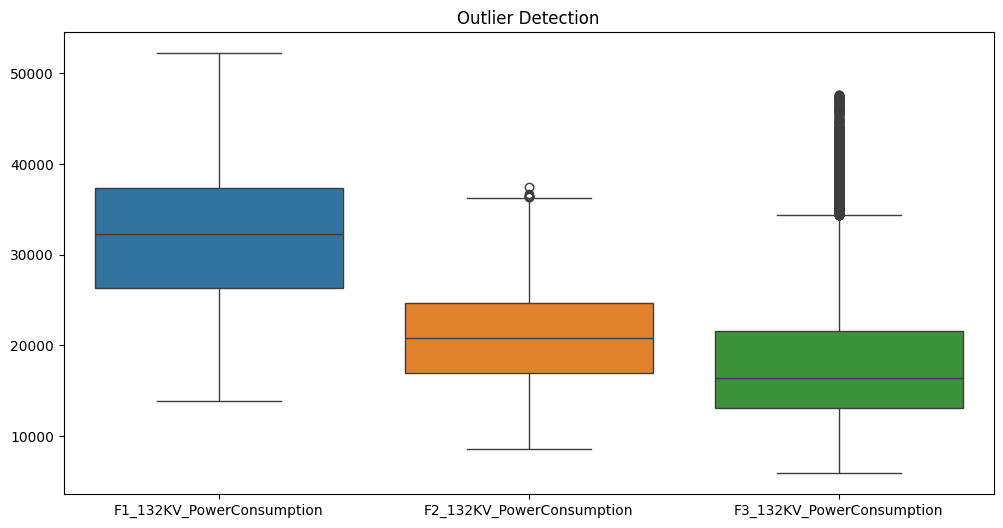

In [9]:
# Boxplot for outlier detection

plt.figure(figsize=(12,6))

sns.boxplot(data=df[power_cols])

plt.title("Outlier Detection")

plt.show()

In [10]:
# IQR based clipping

for col in power_cols:

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df[col] = np.clip(df[col], lower, upper)

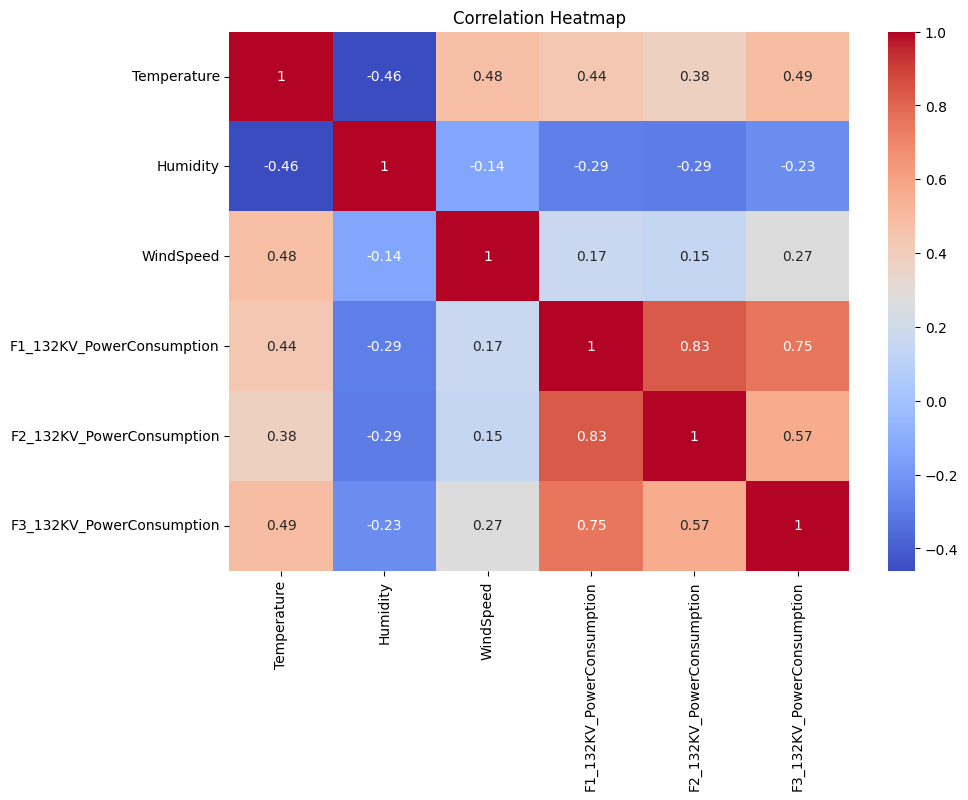

In [11]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [12]:
# Datetime conversion

df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)

df.dropna(subset=["Datetime"], inplace=True)

In [13]:
# Time-based features

df["hour"] = df["Datetime"].dt.hour
df["day"] = df["Datetime"].dt.day
df["month"] = df["Datetime"].dt.month
df["weekday"] = df["Datetime"].dt.weekday

In [14]:
# Target column

target_col = "F1_132KV_PowerConsumption"

In [15]:
# Lag feature

df["lag_1"] = df[target_col].shift(1)

In [16]:
# Rolling mean feature

df["rolling_mean"] = df[target_col].rolling(3).mean()

In [17]:
# Remove null rows after feature engineering

df.dropna(inplace=True)

In [18]:
features = [
    "hour",
    "day",
    "month",
    "weekday",
    "lag_1",
    "rolling_mean"
]

X = df[features]

y = df[target_col]

In [19]:
"""
Why XGBoost?

1. Handles nonlinear relationships effectively
2. High accuracy for time-series/tabular data
3. Robust against overfitting
4. Works well with engineered features
5. Faster training performance
"""

'\nWhy XGBoost?\n\n1. Handles nonlinear relationships effectively\n2. High accuracy for time-series/tabular data\n3. Robust against overfitting\n4. Works well with engineered features\n5. Faster training performance\n'

In [20]:
# Feature scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [21]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
# Model training

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6
)

model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [23]:
# Predictions

predictions = model.predict(X_test)

In [24]:
# MAE

mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 219.81147853614058


In [25]:
# RMSE

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("RMSE:", rmse)

RMSE: 353.1869920167377


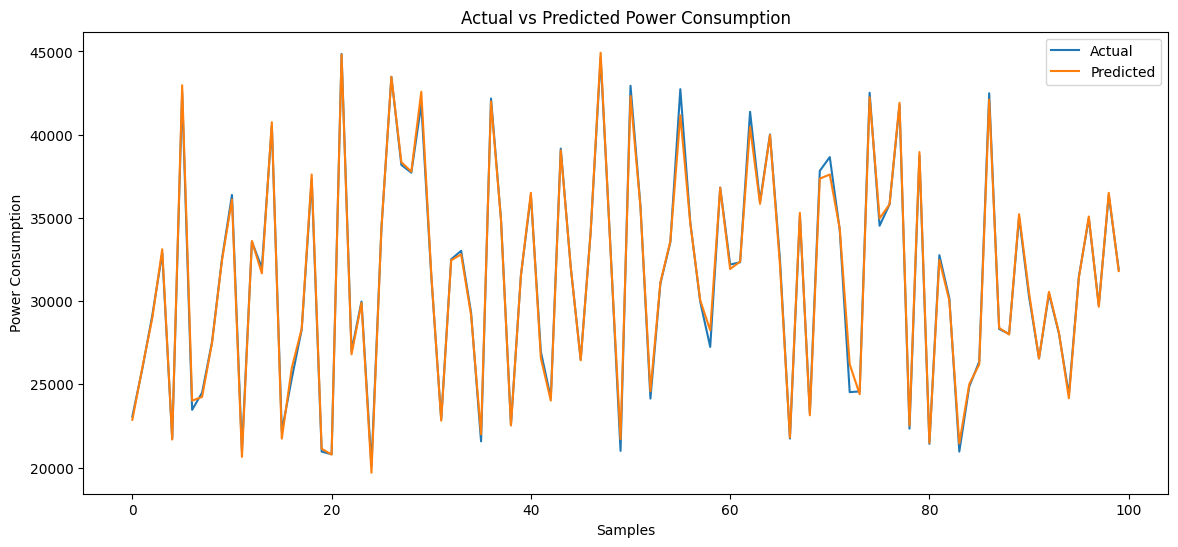

In [26]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values[:100],
    label="Actual"
)

plt.plot(
    predictions[:100],
    label="Predicted"
)

plt.title("Actual vs Predicted Power Consumption")

plt.xlabel("Samples")

plt.ylabel("Power Consumption")

plt.legend()

plt.show()

In [27]:
"""
Conclusion:

- Missing values were handled successfully
- Outliers were treated using IQR clipping
- Feature engineering improved predictive capability
- XGBoost achieved strong forecasting accuracy
- Forecast visualization shows good alignment
between actual and predicted values
"""

'\nConclusion:\n\n- Missing values were handled successfully\n- Outliers were treated using IQR clipping\n- Feature engineering improved predictive capability\n- XGBoost achieved strong forecasting accuracy\n- Forecast visualization shows good alignment\nbetween actual and predicted values\n'